# Muon analysis for CD4 naive T cells

In [2]:
import numpy as np
import pandas as pd
import scanpy as sc
import muon as mu
import muon.atac as ac
import muon.prot as pt
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import median_abs_deviation
import hisepy as hp

In [3]:
plt.rcParams['figure.dpi'] = 100

In [4]:
# define working path
data_path = '/home/workspace/data/preRA_teaseq/EXP-00243/totalVI/'
fig_path = '/home/workspace/data/preRA_teaseq/EXP-00243/totalVI/figures/'
output_path = '/home/workspace/data/preRA_teaseq/EXP-00243/totalVI/output_results/'
# os.mkdir(fig_path)
# os.mkdir(output_path)
# define a project name
proj_name = 'PreRA_TEASeq_CD4T_'

sc.settings.figdir = fig_path
sc.settings.autosave=False
sc.set_figure_params(vector_friendly=True, dpi_save=300)

In [5]:
def save_plot(fig, ax, save):
    if save is not None:
        if ax is not None:
            if fig is not None:
                fig.savefig(save, bbox_inches='tight')
            else:
                raise ValueError("fig is None, cannot save figure.")
        else:
            raise ValueError("ax is None, cannot save figure.")


def filter_limits(df, sign_limit=None, lFCs_limit=None):

    # Define limits if not defined
    if sign_limit is None:
        sign_limit = np.inf
    if lFCs_limit is None:
        lFCs_limit = np.inf

    # Filter by absolute value limits
    msk_sign = df['pvals'] < np.abs(sign_limit)
    msk_lFCs = np.abs(df['logFCs']) < np.abs(lFCs_limit)
    df = df.loc[msk_sign & msk_lFCs]

    return df

def plot_volcano_df(data, x, y, top=5, genes=None, sign_thr=0.05, lFCs_thr=0.5, sign_limit=None, lFCs_limit=None, color_pos='#D62728',
                    color_neg='#1F77B4', color_null='gray', figsize=(7, 5), dpi=100, ax=None, return_fig=False, save=None):
    """
    Plot logFC and p-values from a long formated data-frame.

    Parameters
    ----------
    data : pd.DataFrame
        Results of DEA in long format.
    x : str
        Column name of data storing the logFCs.
    y : str
        Columns name of data storing the p-values.
    top : int
        Number of top differentially expressed features to show.
    sign_thr : float
        Significance threshold for p-values.
    lFCs_thr : float
        Significance threshold for logFCs.
    sign_limit : float
        Limit of p-values to plot in -log10.
    lFCs_limit : float
        Limit of logFCs to plot in absolute value.
    color_pos: str
        Color to plot significant positive genes.
    color_neg: str
        Color to plot significant negative genes.
    color_null: str
        Color to plot rest of the genes.
    figsize : tuple
        Figure size.
    dpi : int
        DPI resolution of figure.
    ax : Axes, None
        A matplotlib axes object. If None returns new figure.
    return_fig : bool
        Whether to return a Figure object or not.
    save : str, None
        Path to where to save the plot. Infer the filetype if ending on {``.pdf``, ``.png``, ``.svg``}.

    Returns
    -------
    fig : Figure, None
        If return_fig, returns Figure object.
    """
    from adjustText import adjust_text
    # # Load plotting packages
    # plt = check_if_matplotlib()
    # at = check_if_adjustText()

    # Transform sign_thr
    sign_thr = -np.log10(sign_thr)

    # Extract df
    df = data.copy()
    df['logFCs'] = df[x]
    df['pvals'] = -np.log10(df[y])

    # Filter by limits
    df = filter_limits(df, sign_limit=sign_limit, lFCs_limit=lFCs_limit)

    # Define color by up or down regulation and significance
    df['weight'] = color_null
    up_msk = (df['logFCs'] >= lFCs_thr) & (df['pvals'] >= sign_thr)
    dw_msk = (df['logFCs'] <= -lFCs_thr) & (df['pvals'] >= sign_thr)
    df.loc[up_msk, 'weight'] = color_pos
    df.loc[dw_msk, 'weight'] = color_neg

    # Plot
    fig = None
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=figsize, dpi=dpi)
    df.plot.scatter(x='logFCs', y='pvals', c='weight', sharex=False, ax=ax)
    ax.set_axisbelow(True)

    # Draw sign lines
    ax.axhline(y=sign_thr, linestyle='--', color="black")
    ax.axvline(x=lFCs_thr, linestyle='--', color="black")
    ax.axvline(x=-lFCs_thr, linestyle='--', color="black")

    if genes is None:
        # Plot top sign features
        signs = df[up_msk | dw_msk].sort_values('pvals', ascending=False)
        signs = signs.iloc[:top]
    else:
        signs = df[up_msk | dw_msk].sort_values('pvals', ascending=False)
        signs = signs.loc[signs.index.isin(genes)]
    # Add labels
    ax.set_ylabel('-log10(pvals)')
    texts = []
    for x, y, s in zip(signs['logFCs'], signs['pvals'], signs.index):
        texts.append(ax.text(x, y, s))
    if len(texts) > 0:
        adjust_text(texts, arrowprops=dict(arrowstyle='-', color='black'), ax=ax)

    save_plot(fig, ax, save)

    if return_fig:
        return fig

### subset cd4 naive cells and run degs

In [ ]:
# load the three modalities data with motif
cd4_mdata = mu.read(data_path+'PreRA_teaseq_cd4_3modality.h5mu')

In [11]:
cd4na_mdata = cd4_mdata[cd4_mdata.obs['Archr_Clusters_0_8'].isin(['C2','C4','C5','C7','C8'])].copy()

/home/jupyter/libs/muon/lib/python3.10/site-packages/mudata/_core/mudata.py:457: UserWarning: Cannot join columns with the same name because var_names are intersecting.
  warnings.warn(


In [8]:
cd4na_mdata

MuData object with n_obs × n_vars = 23860 × 675496
  obs:	'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'barcodes', 'adt_qc_flag', 'adt_umis', 'batch_id', 'cell_name', 'chip_id', 'hto_barcode', 'hto_category', 'n_genes', 'n_mito_umis', 'n_reads', 'n_umis', 'original_barcodes', 'pbmc_sample_id', 'pool_id', 'rna_cell_uuid', 'seurat_pbmc_type', 'seurat_pbmc_type_score', 'umap_1', 'umap_2', 'well_id', 'nCount_ADT', 'nFeature_ADT', 'percent.mt', 'cluster ratio', 'subject_id', 'Ethnicity', 'Race', 'Birth Year', 'Sex', 'cohort', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.5', 'seurat_clusters', 'predicted.celltype.l1.score', 'predicted.celltype.l1', 'predicted.celltype.l2.score', 'predicted.celltype.l2', 'predicted.celltype.l3.score', 'predicted.celltype.l3', 'ADT_snn_res.0.5', 'atac_cell_id', 'n_mito', 'n_fragments', 'peaks_frac', 'altius_frac', 'DoubletScore', 'DoubletEnrichment', 'Clusters', 'iterative_lsi_number_umap_dimension_1', 'iterative_lsi_number_umap_dimension_2', 'nCount_Tiles', 'nFeature_Tiles', 'nCount_cleanadt', 'nFeature_cleanadt', 'cleanadt_snn_res.0.5', 'Tiles_snn_res.0.8', 'SCT.weight', 'ADT.weight', 'Tiles.weight', 'wsnn_res.0.5', 'wsnn_res.0.8', 'l1_cell_types', 'l2_cell_types', 'clean_l2_cell_types', 'nCount_rna', 'nFeature_rna', 'immunehealth_l1', 'immunehealth_l1_conf_score', 'immunehealth_l2', 'immunehealth_l2_conf_score', 'immunehealth_l3', 'immunehealth_l3_conf_score', 'Archr_Clusters_0_8'
  4 modalities
    rna:	23860 x 36601
      obs:	'log10umi', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'predicted_labels', 'conf_score', 'leiden_c3', 'Archr_Clusters_0_8', 'NMF0_Cytotoxic', 'NMF1_Treg', 'NMF2_Th17', 'NMF3_Naive', 'NMF4_Act', 'NMF5_Th2', 'NMF6_Tfh', 'NMF7_IFN', 'NMF8_Cent_Mem', 'NMF9_Thymic_Emi', 'NMF10_Tissue', 'NMF11_Th1'
      var:	'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
      uns:	'Archr_Clusters_0_8_colors', 'Archr_Clusters_0_8_wilcoxon', 'Archr_naive_wilcoxon', 'clean_l2_cell_types_colors', 'dendrogram_Archr_Clusters_0_8', 'hvg', 'immunehealth_l1_colors', 'immunehealth_l2_colors', 'immunehealth_l3_colors', 'l2_cell_types_colors', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'rna:leiden_c3_colors', 'rna:leiden_colors', 'umap'
      obsm:	'X_NMFproj', 'X_pca', 'X_rnaumap', 'X_umap'
      varm:	'PCs'
      layers:	'counts'
      obsp:	'connectivities', 'distances'
    prot:	23860 x 166
      obs:	'Archr_Clusters_0_8'
      uns:	'Archr_Clusters_0_8_colors', 'Archr_naive_wilcoxon', 'clean_l2_cell_types_colors', 'dendrogram_Archr_Clusters_0_8', 'immunehealth_l1_colors', 'immunehealth_l2_colors', 'immunehealth_l3_colors', 'neighbors', 'pca', 'umap'
      obsm:	'X_pca', 'X_umap'
      varm:	'PCs'
      layers:	'counts', 'dsb'
      obsp:	'connectivities', 'distances'
    atac:	23860 x 637859
      obs:	'altius_count', 'altius_frac', 'barcodes', 'batch_id', 'BlacklistRatio', 'cell_name', 'chip_id', 'DoubletEnrichment', 'DoubletScore', 'gene_bodies_count', 'gene_bodies_frac', 'Gex_MitoRatio', 'Gex_nGenes', 'Gex_nUMI', 'Gex_RiboRatio', 'n_duplicate', 'n_fragments', 'n_mito', 'n_unique', 'nDiFrags', 'nFrags', 'nMonoFrags', 'nMultiFrags', 'NucleosomeRatio', 'original_barcodes', 'PassQC', 'pbmc_sample_id', 'peaks_count', 'peaks_frac', 'pool_id', 'PromoterRatio', 'ReadsInBlacklist', 'ReadsInPromoter', 'ReadsInTSS', 'singlet', 'tss_count', 'tss_frac', 'TSSEnrichment', 'well_id', 'Clusters', 'subject_id', 'cohort', 'Birth.Year', 'Sex', 'wsnn_res.0.5', 'l1_cell_types', 'l2_cell_types', 'clean_l2_cell_types', 'ReadsInPeaks', 'FRIP', 'MochaPeak_clusters_1', 'n_genes_by_counts', 'total_counts', 'leiden'
      var:	'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
      uns:	'Archr_Clusters_0_8_colors', 'X_name', 'atac:leiden_colors', 'cohort_colors', 'immunehealth_l2_colors', 'immunehealth_l3_colors', 'leiden', 'neighbors', 'rn

In [ ]:
# write the three modalities data
cd4na_mdata.write(data_path + 'PreRA_teaseq_cd4naive_3modality_motif.h5mu')

In [ ]:
# upload the pseudobulk data for all 141 samples
hp.upload_files(files=['/home/workspace/data/preRA_teaseq/EXP-00243/totalVI/PreRA_teaseq_cd4naive_3modality_motif.h5mu'],
                study_space_id='72ac97bb-a08c-4d89-8180-e4d057be2c70',
                title='preRA TeaSeq CD4 naive T 3modality h5mu',
                input_file_ids=['274cb2ee-23c9-40e7-b75b-980e1e127e61'])

# load data

In [ ]:
# download data
hp.cache_files([''])

In [6]:
# load the three modalities data with motif
cd4na_mdata = mu.read(data_path+'PreRA_teaseq_cd4naive_3modality_motif.h5mu')

/home/workspace/environment/py_scrna/lib/python3.12/site-packages/mudata/_core/mudata.py:1531: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/home/workspace/environment/py_scrna/lib/python3.12/site-packages/mudata/_core/mudata.py:931: UserWarning: Cannot join columns with the same name because var_names are intersecting.
  warnings.warn(
/home/workspace/environment/py_scrna/lib/python3.12/site-packages/mudata/_core/mudata.py:1429: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push

In [7]:
cd4na_mdata

MuData object with n_obs × n_vars = 23860 × 675496
  obs:	'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'barcodes', 'adt_qc_flag', 'adt_umis', 'batch_id', 'cell_name', 'chip_id', 'hto_barcode', 'hto_category', 'n_genes', 'n_mito_umis', 'n_reads', 'n_umis', 'original_barcodes', 'pbmc_sample_id', 'pool_id', 'rna_cell_uuid', 'seurat_pbmc_type', 'seurat_pbmc_type_score', 'umap_1', 'umap_2', 'well_id', 'nCount_ADT', 'nFeature_ADT', 'percent.mt', 'cluster ratio', 'subject_id', 'Ethnicity', 'Race', 'Birth Year', 'Sex', 'cohort', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.5', 'seurat_clusters', 'predicted.celltype.l1.score', 'predicted.celltype.l1', 'predicted.celltype.l2.score', 'predicted.celltype.l2', 'predicted.celltype.l3.score', 'predicted.celltype.l3', 'ADT_snn_res.0.5', 'atac_cell_id', 'n_mito', 'n_fragments', 'peaks_frac', 'altius_frac', 'DoubletScore', 'DoubletEnrichment', 'Clusters', 'iterative_lsi_number_umap_dimension_1', 'iterative_lsi_number_umap_dimension_2', 'nCount_Tiles', 'nFeature_Tiles', 'nCount_cleanadt', 'nFeature_cleanadt', 'cleanadt_snn_res.0.5', 'Tiles_snn_res.0.8', 'SCT.weight', 'ADT.weight', 'Tiles.weight', 'wsnn_res.0.5', 'wsnn_res.0.8', 'l1_cell_types', 'l2_cell_types', 'clean_l2_cell_types', 'nCount_rna', 'nFeature_rna', 'immunehealth_l1', 'immunehealth_l1_conf_score', 'immunehealth_l2', 'immunehealth_l2_conf_score', 'immunehealth_l3', 'immunehealth_l3_conf_score', 'Archr_Clusters_0_8'
  4 modalities
    rna:	23860 x 36601
      obs:	'log10umi', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'predicted_labels', 'conf_score', 'leiden_c3', 'Archr_Clusters_0_8', 'NMF0_Cytotoxic', 'NMF1_Treg', 'NMF2_Th17', 'NMF3_Naive', 'NMF4_Act', 'NMF5_Th2', 'NMF6_Tfh', 'NMF7_IFN', 'NMF8_Cent_Mem', 'NMF9_Thymic_Emi', 'NMF10_Tissue', 'NMF11_Th1'
      var:	'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
      uns:	'Archr_Clusters_0_8_colors', 'Archr_Clusters_0_8_wilcoxon', 'Archr_naive_wilcoxon', 'clean_l2_cell_types_colors', 'dendrogram_Archr_Clusters_0_8', 'hvg', 'immunehealth_l1_colors', 'immunehealth_l2_colors', 'immunehealth_l3_colors', 'l2_cell_types_colors', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'rna:leiden_c3_colors', 'rna:leiden_colors', 'umap'
      obsm:	'X_NMFproj', 'X_pca', 'X_rnaumap', 'X_umap'
      varm:	'PCs'
      layers:	'counts'
      obsp:	'connectivities', 'distances'
    prot:	23860 x 166
      obs:	'Archr_Clusters_0_8'
      uns:	'Archr_Clusters_0_8_colors', 'Archr_naive_wilcoxon', 'clean_l2_cell_types_colors', 'dendrogram_Archr_Clusters_0_8', 'immunehealth_l1_colors', 'immunehealth_l2_colors', 'immunehealth_l3_colors', 'neighbors', 'pca', 'umap'
      obsm:	'X_pca', 'X_umap'
      varm:	'PCs'
      layers:	'counts', 'dsb'
      obsp:	'connectivities', 'distances'
    atac:	23860 x 637859
      obs:	'altius_count', 'altius_frac', 'barcodes', 'batch_id', 'BlacklistRatio', 'cell_name', 'chip_id', 'DoubletEnrichment', 'DoubletScore', 'gene_bodies_count', 'gene_bodies_frac', 'Gex_MitoRatio', 'Gex_nGenes', 'Gex_nUMI', 'Gex_RiboRatio', 'n_duplicate', 'n_fragments', 'n_mito', 'n_unique', 'nDiFrags', 'nFrags', 'nMonoFrags', 'nMultiFrags', 'NucleosomeRatio', 'original_barcodes', 'PassQC', 'pbmc_sample_id', 'peaks_count', 'peaks_frac', 'pool_id', 'PromoterRatio', 'ReadsInBlacklist', 'ReadsInPromoter', 'ReadsInTSS', 'singlet', 'tss_count', 'tss_frac', 'TSSEnrichment', 'well_id', 'Clusters', 'subject_id', 'cohort', 'Birth.Year', 'Sex', 'wsnn_res.0.5', 'l1_cell_types', 'l2_cell_types', 'clean_l2_cell_types', 'ReadsInPeaks', 'FRIP', 'MochaPeak_clusters_1', 'n_genes_by_counts', 'total_counts', 'leiden'
      var:	'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
      uns:	'Archr_Clusters_0_8_colors', 'X_name', 'atac:leiden_colors', 'cohort_colors', 'immunehealth_l2_colors', 'immunehealth_l3_colors', 'leiden', 'neighbors', 'rn

# test atac cluster degs and adts in naive cells

In [49]:
cd4na_mdata

MuData object with n_obs × n_vars = 23860 × 674626
  obs:	'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'barcodes', 'adt_qc_flag', 'adt_umis', 'batch_id', 'cell_name', 'chip_id', 'hto_barcode', 'hto_category', 'n_genes', 'n_mito_umis', 'n_reads', 'n_umis', 'original_barcodes', 'pbmc_sample_id', 'pool_id', 'rna_cell_uuid', 'seurat_pbmc_type', 'seurat_pbmc_type_score', 'umap_1', 'umap_2', 'well_id', 'nCount_ADT', 'nFeature_ADT', 'percent.mt', 'cluster ratio', 'subject_id', 'Ethnicity', 'Race', 'Birth Year', 'Sex', 'cohort', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.5', 'seurat_clusters', 'predicted.celltype.l1.score', 'predicted.celltype.l1', 'predicted.celltype.l2.score', 'predicted.celltype.l2', 'predicted.celltype.l3.score', 'predicted.celltype.l3', 'ADT_snn_res.0.5', 'atac_cell_id', 'n_mito', 'n_fragments', 'peaks_frac', 'altius_frac', 'DoubletScore', 'DoubletEnrichment', 'Clusters', 'iterative_lsi_number_umap_dimension_1', 'iterative_lsi_number_umap_dimension_2', 'nCount_Tiles', 'nFeature_Tiles', 'nCount_cleanadt', 'nFeature_cleanadt', 'cleanadt_snn_res.0.5', 'Tiles_snn_res.0.8', 'SCT.weight', 'ADT.weight', 'Tiles.weight', 'wsnn_res.0.5', 'wsnn_res.0.8', 'l1_cell_types', 'l2_cell_types', 'clean_l2_cell_types', 'nCount_rna', 'nFeature_rna', 'immunehealth_l1', 'immunehealth_l1_conf_score', 'immunehealth_l2', 'immunehealth_l2_conf_score', 'immunehealth_l3', 'immunehealth_l3_conf_score', 'leiden_wnn', 'Archr_Clusters_0_8', 'leiden_wnn_1_2'
  obsm:	'X_umap'
  obsp:	'wnn_connectivities', 'wnn_distances'
  3 modalities
    rna:	23860 x 36601
      obs:	'log10umi', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'predicted_labels', 'conf_score', 'leiden_c3', 'Archr_Clusters_0_8', 'NMF0_Cytotoxic', 'NMF1_Treg', 'NMF2_Th17', 'NMF3_Naive', 'NMF4_Act', 'NMF5_Th2', 'NMF6_Tfh', 'NMF7_IFN', 'NMF8_Cent_Mem', 'NMF9_Thymic_Emi', 'NMF10_Tissue', 'NMF11_Th1'
      var:	'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
      uns:	'Archr_Clusters_0_8_colors', 'Archr_Clusters_0_8_wilcoxon', 'Archr_naive_wilcoxon', 'clean_l2_cell_types_colors', 'cohort_colors', 'dendrogram_Archr_Clusters_0_8', 'dendrogram_leiden', 'hvg', 'immunehealth_l1_colors', 'immunehealth_l2_colors', 'immunehealth_l3_colors', 'l2_cell_types_colors', 'leiden', 'leiden_colors', 'leiden_wilcoxon', 'leiden_wilcoxon_C10vsC0', 'log1p', 'neighbors', 'pca', 'rna:leiden_c3_colors', 'rna:leiden_colors', 'umap'
      obsm:	'X_NMFproj', 'X_pca', 'X_rnaumap', 'X_umap'
      varm:	'PCs'
      layers:	'counts'
      obsp:	'connectivities', 'distances'
    prot:	23860 x 166
      var:	'highly_variable', 'means', 'dispersions', 'dispersions_norm'
      uns:	'clean_l2_cell_types_colors', 'hvg', 'immunehealth_l1_colors', 'immunehealth_l2_colors', 'immunehealth_l3_colors', 'neighbors', 'pca', 'umap'
      obsm:	'X_pca', 'X_umap'
      varm:	'PCs'
      layers:	'counts', 'dsb'
      obsp:	'connectivities', 'distances'
    atac:	23860 x 637859
      obs:	'altius_count', 'altius_frac', 'barcodes', 'batch_id', 'BlacklistRatio', 'cell_name', 'chip_id', 'DoubletEnrichment', 'DoubletScore', 'gene_bodies_count', 'gene_bodies_frac', 'Gex_MitoRatio', 'Gex_nGenes', 'Gex_nUMI', 'Gex_RiboRatio', 'n_duplicate', 'n_fragments', 'n_mito', 'n_unique', 'nDiFrags', 'nFrags', 'nMonoFrags', 'nMultiFrags', 'NucleosomeRatio', 'original_barcodes', 'PassQC', 'pbmc_sample_id', 'peaks_count', 'peaks_frac', 'pool_id', 'PromoterRatio', 'ReadsInBlacklist', 'ReadsInPromoter', 'ReadsInTSS', 'singlet', 'tss_count', 'tss_frac', 'TSSEnrichment', 'well_id', 'Clusters', 'subject_id', 'cohort', 'Birth.Year', 'Sex', 'wsnn_res.0.5', 'l1_cell_types', 'l2_cell_types', 'clean_l2_cell_types', 'ReadsInPeaks', 'FRIP', 'MochaPeak_clusters_1', 'n_genes_by_counts', 'total_counts', 'leiden'
      var:	'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
      uns:	'Archr_Clusters

In [50]:
cd4na_mdata.obs['Archr_Clusters_0_8'] = cd4na_mdata.obs['Archr_Clusters_0_8'].astype('str').astype('category').copy()

In [51]:
rna = cd4na_mdata['rna']
rna.obs['Archr_Clusters_0_8'] = cd4na_mdata.obs['Archr_Clusters_0_8'].copy()


In [52]:
# test on degs
sc.tl.rank_genes_groups(rna, groupby='Archr_Clusters_0_8', 
                        method='wilcoxon', key_added='Archr_naive_wilcoxon')

In [9]:
cd4na_mdata.obs['Archr_Clusters_0_8'].astype('str').astype('category')

bd196bb4867611ec8396aea599a86ab5    C4
bd19c73a867611ec8396aea599a86ab5    C7
bd1eff66867611ec8396aea599a86ab5    C7
bd2d0aca867611ec8396aea599a86ab5    C4
bd33a48e867611ec8396aea599a86ab5    C8
                                    ..
695694ae867911ecb648ee55e4236e76    C8
69576a1e867911ecb648ee55e4236e76    C7
6962cf26867911ecb648ee55e4236e76    C4
69668daa867911ecb648ee55e4236e76    C7
697e34be867911ecb648ee55e4236e76    C8
Name: Archr_Clusters_0_8, Length: 23860, dtype: category
Categories (5, object): ['C2', 'C4', 'C5', 'C7', 'C8']

In [55]:
sc.tl.dendrogram(cd4na_mdata['rna'], groupby='Archr_Clusters_0_8')

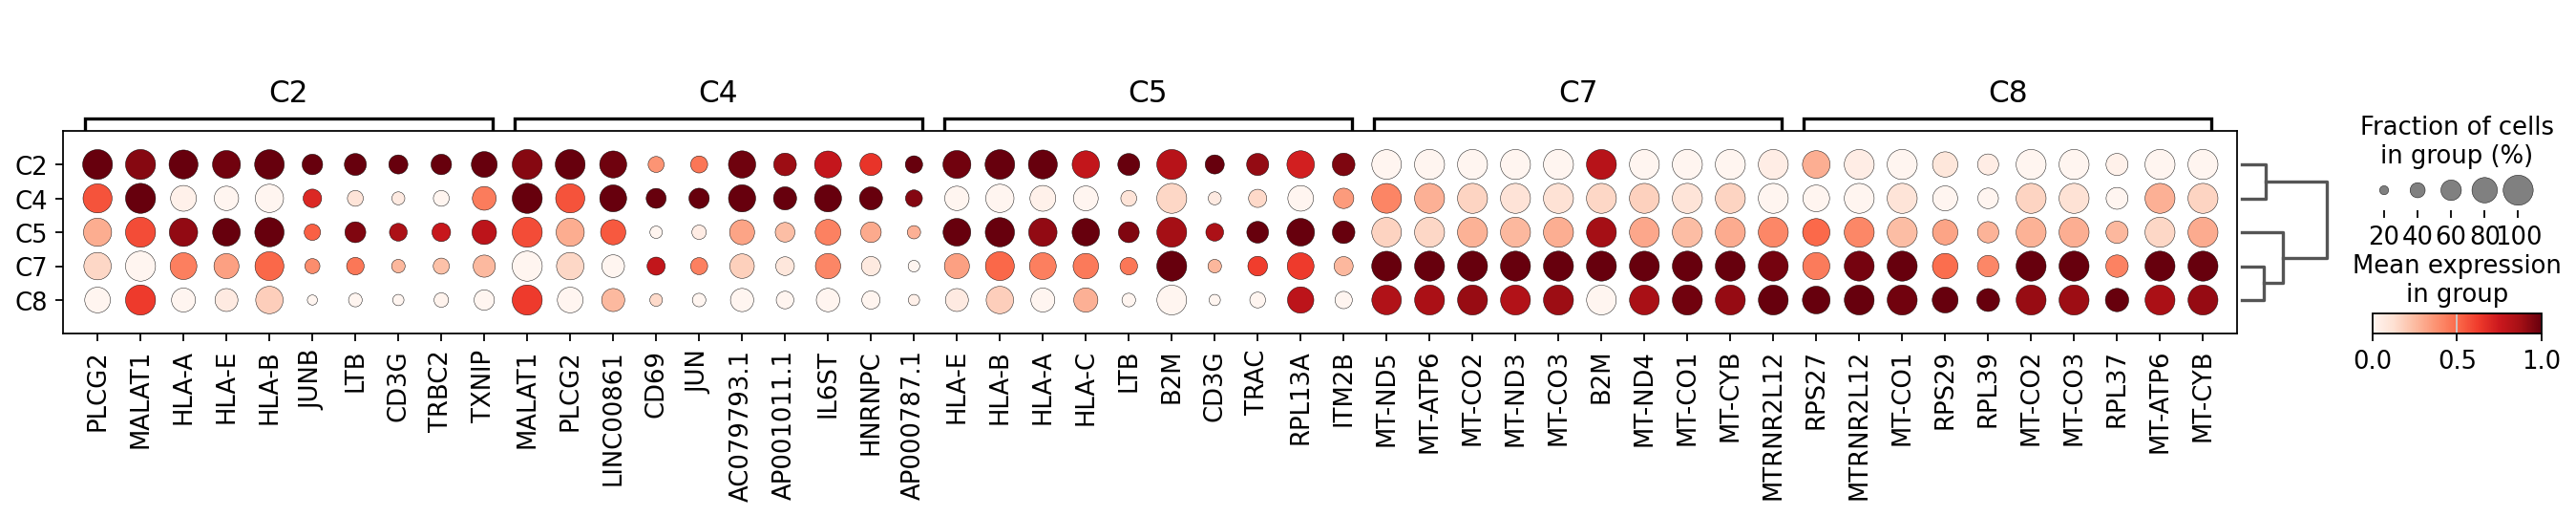

In [6]:
cluster_name = 'Archr_Clusters_0_8'
sc.pl.rank_genes_groups_dotplot(
    cd4na_mdata['rna'], groupby=cluster_name, standard_scale="var", 
    n_genes=10, key="Archr_naive_wilcoxon",
    save= '_'+ proj_name+ cluster_name+'_naive_top_genes_dotplot_scale.pdf'
)

In [10]:
# output the deg list
cluster_name = 'Archr_Clusters_0_8'
leiden_degs = sc.get.rank_genes_groups_df(cd4na_mdata['rna'], key= 'Archr_naive_wilcoxon',
                                              pval_cutoff=None,  group=None).rename(
    {'group':cluster_name},  axis='columns')
leiden_degs['direction'] = np.where(leiden_degs['logfoldchanges']>0, 'up', 'down')
leiden_degs = leiden_degs.reindex(leiden_degs['scores'].abs().sort_values(ascending=False).index)
# leiden_degs.loc[leiden_degs['pvals_adj']<0.01]

In [11]:
C2_degs = leiden_degs.loc[leiden_degs['Archr_Clusters_0_8']=='C2'].set_index('names')
C2_degs.loc[C2_degs['pvals_adj']==0, 'pvals_adj'] = C2_degs.loc[C2_degs['pvals_adj']>0, 'pvals_adj'].min()

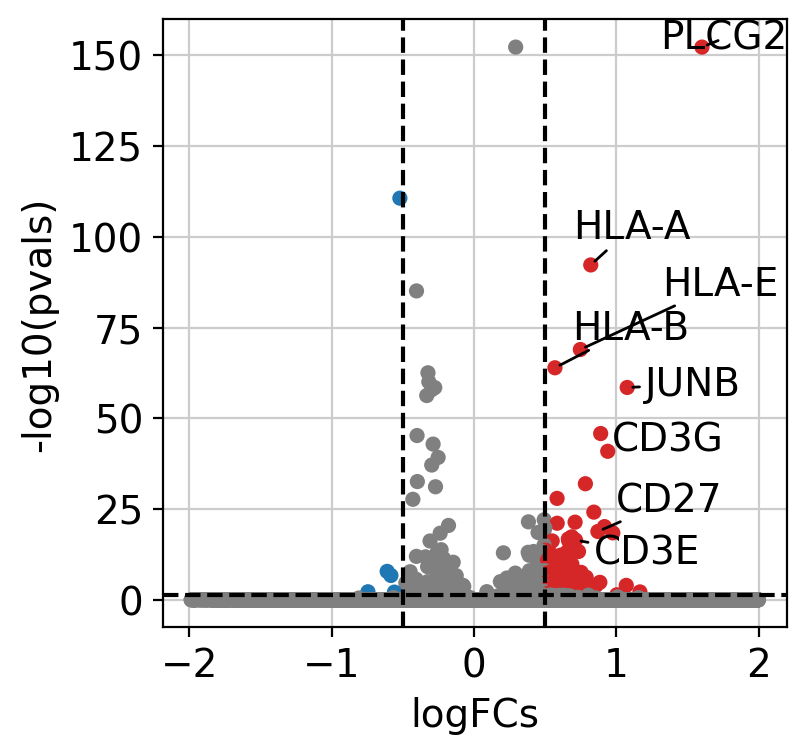

In [15]:
plot_volcano_df(
    C2_degs,
    x='logfoldchanges',
    y='pvals_adj', genes=['PLCG2', 'HLA-A', 'HLA-E', 'HLA-B', 'MRE11A',
                          'JUNB','IL7R', 'LCK', 'CD27', 'CD3E', 'CD3G'],
    lFCs_thr=0.5,
    lFCs_limit=2,
    figsize=(4, 4)
)


## test protein

In [57]:
cd4na_mdata['prot'].obs['Archr_Clusters_0_8'] = cd4na_mdata.obs['Archr_Clusters_0_8'].copy()

In [58]:
cd4na_mdata.obs['Archr_Clusters_0_8'].value_counts()

Archr_Clusters_0_8
C4    6493
C8    6269
C7    5518
C5    3760
C2    1820
Name: count, dtype: int64

In [59]:
cd4na_mdata['prot'].X == cd4na_mdata['prot'].layers['dsb']

array([[ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       ...,
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True]])

In [60]:
cd4na_mdata['prot']

AnnData object with n_obs × n_vars = 23860 × 166
    obs: 'Archr_Clusters_0_8'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'clean_l2_cell_types_colors', 'hvg', 'immunehealth_l1_colors', 'immunehealth_l2_colors', 'immunehealth_l3_colors', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts', 'dsb'
    obsp: 'connectivities', 'distances'

In [61]:
# test on degs
sc.tl.rank_genes_groups(cd4na_mdata['prot'], groupby='Archr_Clusters_0_8', 
                        method='wilcoxon', key_added='Archr_naive_wilcoxon')

/home/jupyter/libs/muon/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:420: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, 'logfoldchanges'] = np.log2(
/home/jupyter/libs/muon/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:420: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, 'logfoldchanges'] = np.log2(
/home/jupyter/libs/muon/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:420: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, 'logfoldchanges'] = np.log2(


In [77]:
# output the deg list
cluster_name = 'Archr_Clusters_0_8'
leiden_deps = sc.get.rank_genes_groups_df(cd4na_mdata['prot'], key= 'Archr_naive_wilcoxon',
                                              pval_cutoff=None,  group=None).rename(
    {'group':cluster_name},  axis='columns')
leiden_deps['direction'] = np.where(leiden_deps['logfoldchanges']>0, 'up', 'down')
leiden_deps = leiden_deps.reindex(leiden_deps['scores'].abs().sort_values(ascending=False).index)
leiden_deps.loc[leiden_deps['pvals_adj']<0.01]

,Archr_Clusters_0_8,names,scores,logfoldchanges,pvals,pvals_adj,direction
497,C5,CD62L,-51.962440,-4.453210,0.000000e+00,0.000000e+00,down
496,C5,CD162,-47.937756,-2.421912,0.000000e+00,0.000000e+00,down
498,C7,CD62L,36.932323,1.767457,1.400044e-298,2.324074e-296,up
165,C2,CD62L,-34.484379,-4.149714,1.375535e-260,2.283389e-258,down
495,C5,CD55,-30.413002,-1.600164,3.697708e-203,2.046065e-201,down
...,...,...,...,...,...,...,...
653,C7,CD146,-3.121068,-0.571880,1.801963e-03,4.985430e-03,down
811,C8,CD71,-3.095976,-0.202635,1.961663e-03,7.942344e-03,down
652,C7,TCR_Va7_2,-3.035535,-0.510818,2.401094e-03,6.534125e-03,down
547,C7,CD36,2.992963,0.340873,2.762829e-03,7.397253e-03,up


In [88]:
leiden_deps.loc[(leiden_deps['pvals_adj']<0.01)&
    (leiden_deps['Archr_Clusters_0_8']=='C2')].head(10)

,Archr_Clusters_0_8,names,scores,logfoldchanges,pvals,pvals_adj,direction
165,C2,CD62L,-34.484379,-4.149714,1.375535e-260,2.283389e-258,down
164,C2,CD162,-30.364914,-2.092487,1.596812e-202,1.325354e-200,down
163,C2,CD47,-15.245686,-0.628201,1.758764e-52,9.731827e-51,down
162,C2,CD55,-14.277687,-0.998878,3.014402e-46,1.250977e-44,down
161,C2,CD44,-13.177864,-0.681580,1.176761e-39,3.906848e-38,down
160,C2,CD7,-12.797196,-1.336479,1.699780e-37,4.702723e-36,down
159,C2,CD9,-12.112432,-1.240402,9.076243e-34,2.152366e-32,down
158,C2,CD49f,-11.629534,-1.012375,2.916856e-31,6.052477e-30,down
157,C2,CD31,-10.793105,-1.243373,3.710359e-27,6.843550e-26,down
156,C2,CD45RA,-10.686020,-0.843408,1.183407e-26,1.964456e-25,down


In [67]:
sc.tl.dendrogram(cd4na_mdata['prot'], groupby='Archr_Clusters_0_8')

/home/jupyter/libs/muon/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:749: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


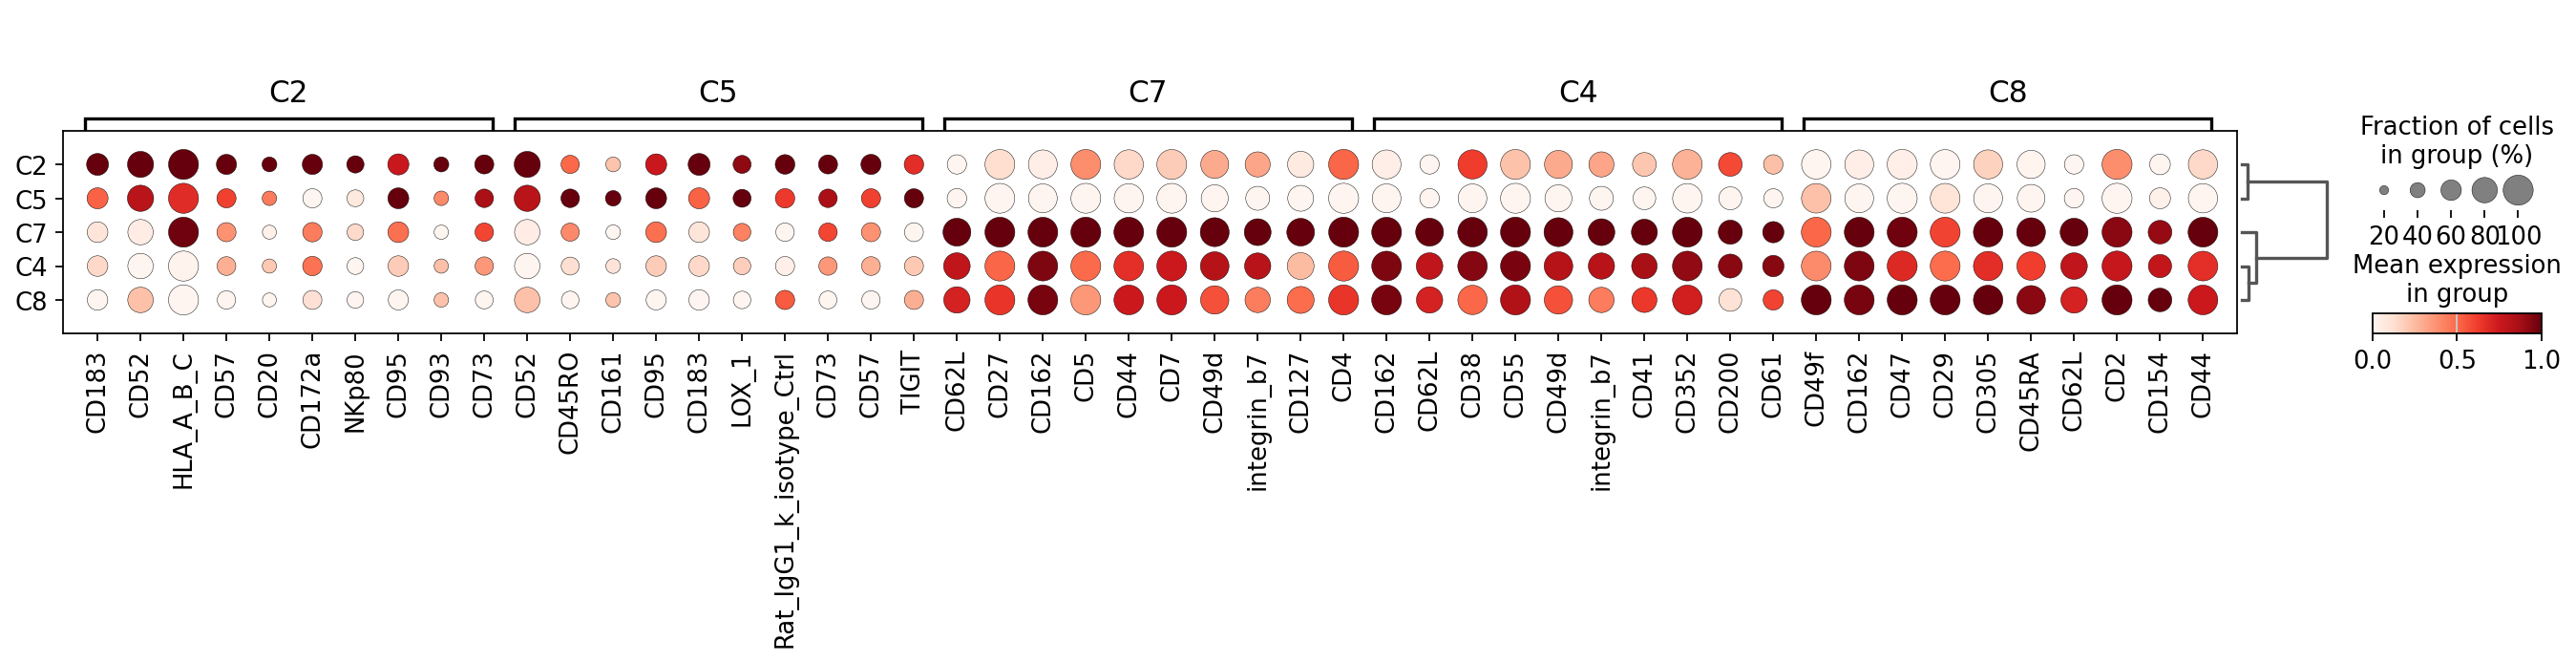

In [87]:
cluster_name = 'Archr_Clusters_0_8'
sc.pl.rank_genes_groups_dotplot(
    cd4na_mdata['prot'], groupby=cluster_name, standard_scale="var", 
    n_genes=10, key="Archr_naive_wilcoxon",
    save= '_'+ proj_name+ cluster_name + '_naive_top_adt_dotplot_scale.pdf'
)

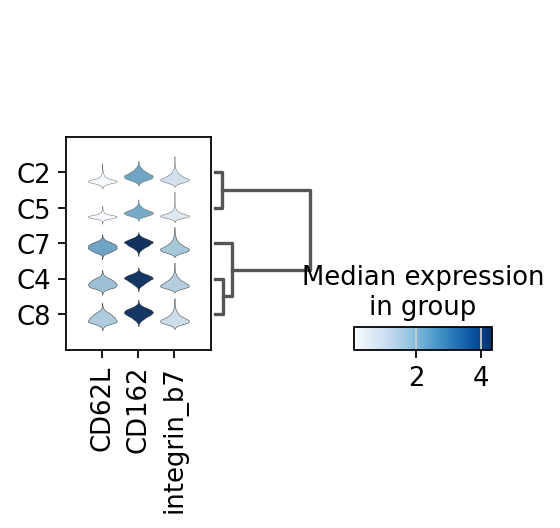

In [86]:
markers = [ 'CD62L', 'CD162', 'integrin_b7']
sc.pl.stacked_violin(cd4na_mdata['prot'], markers, groupby='Archr_Clusters_0_8', dendrogram=True)

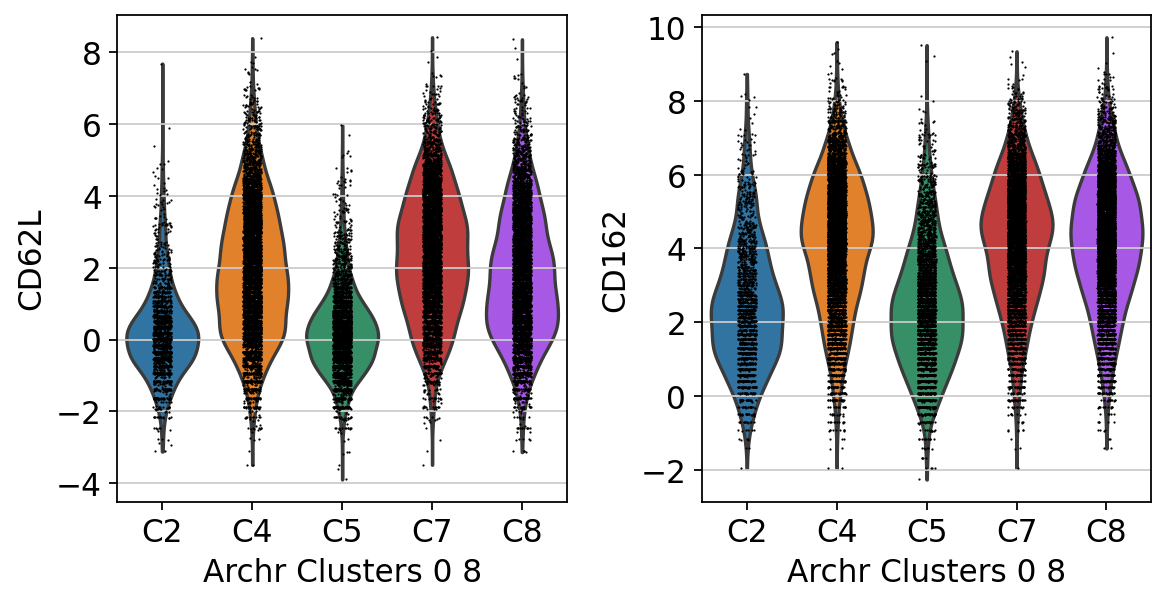

In [91]:
sc.pl.violin(cd4na_mdata['prot'],[ 'CD62L', 'CD162'] , multi_panel=True,
             groupby='Archr_Clusters_0_8',
            save= '_'+ proj_name+ cluster_name + '_naive_CD62L_CD162_violin.png')

In [21]:
cd4na_mdata['rna'].var[cd4na_mdata['rna'].var.index=='MRE11A']

,mt,n_cells_by_counts,mean_counts,pct_dropout_by_counts,total_counts,highly_variable,means,dispersions,dispersions_norm,mean,std


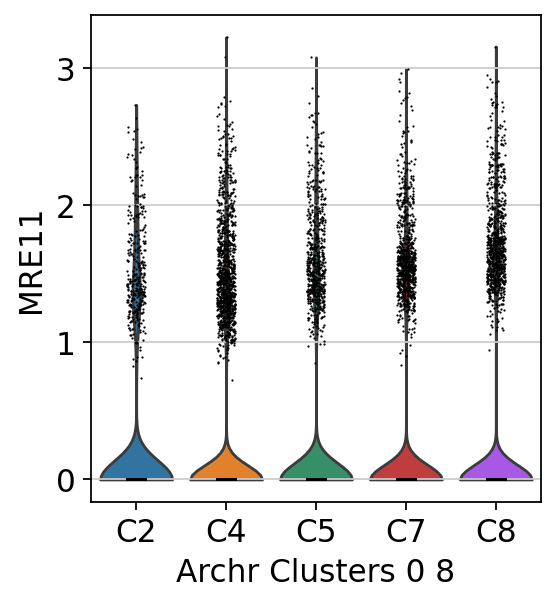

In [22]:
sc.pl.violin(cd4na_mdata['rna'],[ 'MRE11'] , #multi_panel=True,
             groupby='Archr_Clusters_0_8',
            save= '_'+ proj_name+ cluster_name + '_naive_MRE11A_violin.png')

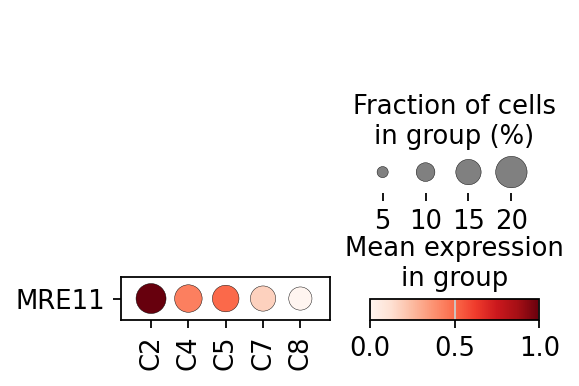

In [24]:
p1 = sc.pl.dotplot(cd4na_mdata['rna'], ['MRE11'],  groupby='Archr_Clusters_0_8', swap_axes=True,
                   standard_scale='var')

In [ ]:
# plot the umap
mu.pl.embedding(cd4na_mdata, basis="atac:X_ArchRumap", 
                color=['prot:CD183',
                       'prot:CD52','prot:CD161','prot:CD95','prot:TIGIT',  'prot:HLA_A_B_C',  'prot:CD62L',               
                       'Archr_Clusters_0_8'], 
                ncols=3,#vmin ='p1', vmax ='p99',
    save=  proj_name+'CD4na_protein_markers_Archr_Clusters_0_8_umap.png')

In [ ]:
import session_info
session_info.show()